**Project 3 - Unsupervised Learning**
- Naranjavkhlan Tumenbold - 6586748
- Kevin Wilson - 625519
- Javier Pessela - 6504395

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import pairwise_distances_argmin

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True


#1 Data preprocessing


1.1 EDA and data cleaning

While cleaning the training data, it is trivial that features such as lucky_number and student_id because they will not have any importance in final decision. Therefore, we impute those features from the feature space.

------------------------------------------------------

To handle the missing data, our team substituted the missing values with the median values, which are more robust to outliers. We drop duplicated columns from our training data(Elaborate more here later).


------------------------------------------------------
In unsupervised learning, the main goal is to find the hidden pattern and clusters which completely differs from supervised learning, whose goal is to find the relationship between features.

Shape: (403, 6)


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number
0,1,4.3,6.2,53.0,30.2,34
1,2,2.4,7.6,67.9,39.9,34
2,3,6.5,8.2,66.0,93.3,85
3,4,3.8,5.4,79.1,NaN,73
4,5,7.7,7.5,NaN,74.3,48


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number
count,403.000000,403.000000,391.000000,392.000000,391.000000,403.000000
mean,202.000000,6.317122,6.401790,74.806888,64.441176,49.759305
std,116.480327,2.548540,1.626833,15.752901,16.206720,28.533198
min,1.000000,1.000000,-2.000000,40.000000,30.000000,1.000000
25%,101.500000,4.500000,5.400000,63.900000,53.550000,26.000000
50%,202.000000,6.600000,6.600000,77.400000,65.300000,51.000000
75%,302.500000,8.100000,7.500000,84.925000,75.700000,73.000000
max,403.000000,12.000000,10.000000,150.000000,95.000000,99.000000


student_id          0
hours_studied       0
sleep_hours        12
attendance_rate    11
prev_exam_score    12
lucky_number        0
dtype: int64
Duplicates: 0


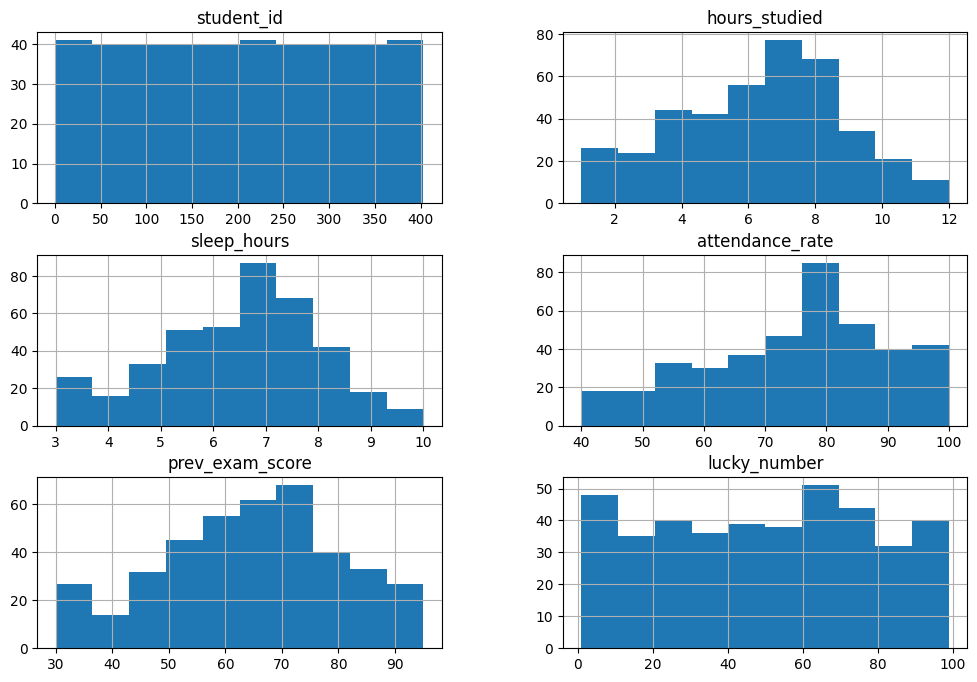

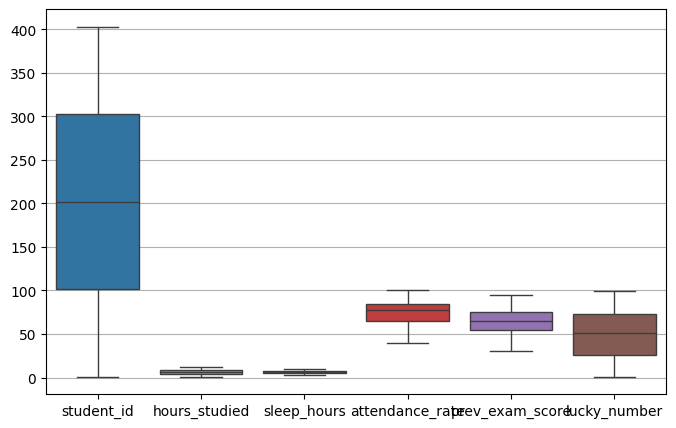

In [2]:
df = pd.read_csv("p3_students_unlabeled.csv")

print("Shape:", df.shape)
display(df.head())
display(df.describe())
print(df.isna().sum())
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Replace impossible values
ranges = {
    "hours_studied": (1,12),
    "sleep_hours": (3,10),
    "attendance_rate": (40,100),
    "prev_exam_score": (30,95)
}

for col,(low,high) in ranges.items():
    df.loc[(df[col]<low)|(df[col]>high),col] = np.nan

# Fill missing with median
for col in df.columns:
    if df[col].dtype != "object":
        df[col] = df[col].fillna(df[col].median())

# Plots
df.hist(figsize=(12,8))
plt.show()

sns.boxplot(data=df.select_dtypes(include=np.number))
plt.show()

1.2 Feature selection and normalization

Normalization is especially crucial for distance based algorithms because it prevents feature domination. Let's assume that attendance rate = [40,100] and sleep hours = [3-10], as we calculate the distance d(x,y) = sqrt(sum(xi-yi)^2), attendance rate will skew the final output. To prevent this domination, we normalize the data to provide fair influence from each features.

In [3]:
features = ["hours_studied","sleep_hours","attendance_rate","prev_exam_score"]

X = df[features]

print("Before normalization:")
display(X.agg(["mean","std"]).T)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("After normalization:")
display(X_scaled_df.agg(["mean","std"]).T)

student_ids = df["student_id"]

Before normalization:


,mean,std
hours_studied,6.317122,2.548540
sleep_hours,6.429032,1.546775
attendance_rate,74.694541,15.082169
prev_exam_score,64.466749,15.963665


After normalization:


,mean,std
hours_studied,2.380230e-16,1.001243
sleep_hours,7.493317e-16,1.001243
attendance_rate,-2.424308e-16,1.001243
prev_exam_score,4.848617e-16,1.001243


#2 K-means clustering


### 2.1 NumPy Implementation Analysis

**Centroid Interpretation:**
- Cluster 0: Represents students with lower study hours (4.47), lower sleep (5.46), and lower previous exam scores (53.3). These appear to be students at risk of failing.
-Cluster 1: Represents students with higher study hours (7.72), more sleep (7.16), and significantly higher attendance and previous scores. These appear to be high-performing students.

-------------------------------------------------------------
- Seed Consistency: Running the algorithm with seeds 0, 42, and 123 resulted in an identical final WCSS of 1004.80 and similar clusters. This indicates that the dataset has a clear structure that is not sensitive to initial centroid placement.

In [4]:
def kmeans_numpy(X, k, max_iters, seed):
    np.random.seed(seed)
    n = X.shape[0]
    # Random initial centroid
    centroids = X[np.random.choice(n, k, replace=False)]
    wcss_history = []

    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        wcss = sum(((X[labels == i] - centroids[i])**2).sum() for i in range(k))
        wcss_history.append(wcss)

        new_centroids = []
        for i in range(k):
            pts = X[labels == i]
            if len(pts) == 0:
                # Handle empty cluster: initialize to a random point from X
                new_centroids.append(X[np.random.randint(0, n)])
            else:
                new_centroids.append(pts.mean(axis=0))

        new_centroids = np.array(new_centroids)

        # Check for convergence
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, labels, wcss_history

Consistency Check across Seeds:
Seed 0: Final WCSS = 1004.80, Cluster Sizes = [229 174]
Seed 42: Final WCSS = 1004.80, Cluster Sizes = [174 229]
Seed 123: Final WCSS = 1004.80, Cluster Sizes = [174 229]
Seed 127: Final WCSS = 1004.80, Cluster Sizes = [175 228]
Seed None: Final WCSS = 1004.80, Cluster Sizes = [229 174]


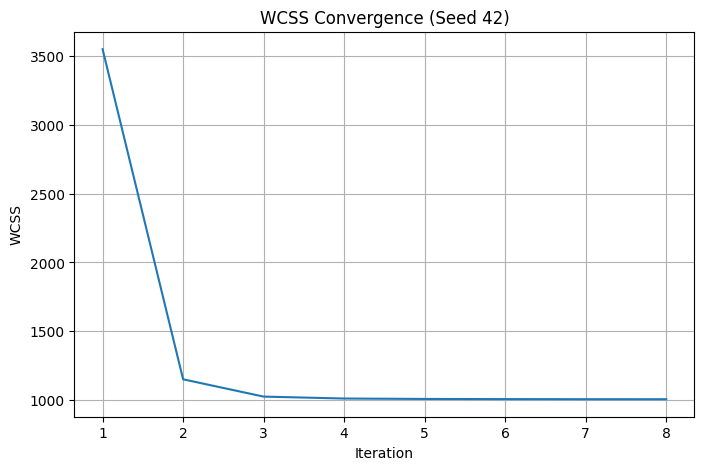

In [5]:
seeds = [0, 42, 123, 127, None]
results_seeds = {}

for s in seeds:
    c, l, h = kmeans_numpy(X_scaled, k=2, max_iters=100, seed=s)
    results_seeds[s] = {"wcss": h[-1], "counts": np.bincount(l)}

print("Consistency Check across Seeds:")
for s, res in results_seeds.items():
    print(f"Seed {s}: Final WCSS = {res['wcss']:.2f}, Cluster Sizes = {res['counts']}")


centroids_np, labels_np, wcss_history = kmeans_numpy(X_scaled, k=2, max_iters=100, seed=42)
plt.plot(range(1, len(wcss_history) + 1), wcss_history)
plt.title("WCSS Convergence (Seed 42)")
plt.xlabel("Iteration")
plt.ylabel("WCSS")
plt.show()

2.2 Sklearn verification
Explain why small differences may exist between your implementation and sklearn
(hint: sklearn uses n_init=10 by default)

Explanation: Sklearn's default settings n_init = 10 means that the algorithm runs multiple times on multiple seeds and then it returns the best cluster with the lowest WCSS. K-means algorithm is sensitive to the initialization, therefore it can stuck in local maximum and our (NumPy) centroids can differ from Sklearn verification.

In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_sk = kmeans.fit_predict(X_scaled)

centroids_sk = scaler.inverse_transform(kmeans.cluster_centers_)

display(pd.DataFrame(centroids_sk, columns=features))

diff = np.sum(labels_np != labels_sk)
print("Different assignments:", diff)

,hours_studied,sleep_hours,attendance_rate,prev_exam_score
0,4.490857,5.465714,63.333714,53.299429
1,7.718860,7.168421,83.414474,73.038158


Different assignments: 1


2.3 Elbow method


Elbow method is easy identify as WCSS significantly decreases as k increases. Because as K increases, clusters become more smaller and specialized. Elbow point is not always clear to identify. Cases such as cluster overlap, weak structure, outliers make the elbow point hard to identify. In our case, k=2 is our elbow point. From this point, as k increases, we do not see significant decrease in WCSS. In conclusion, if I were a university administrator, I would consider both k=2 and k=3, depending on my target. For instance, if I want to categorize students into 2 section such as Students-Low-Performance vs. Students-High Performance. I would use k=3 in case of High-Perf vs. Mid-Perf vs. Low Perf. It really depends on the situation.

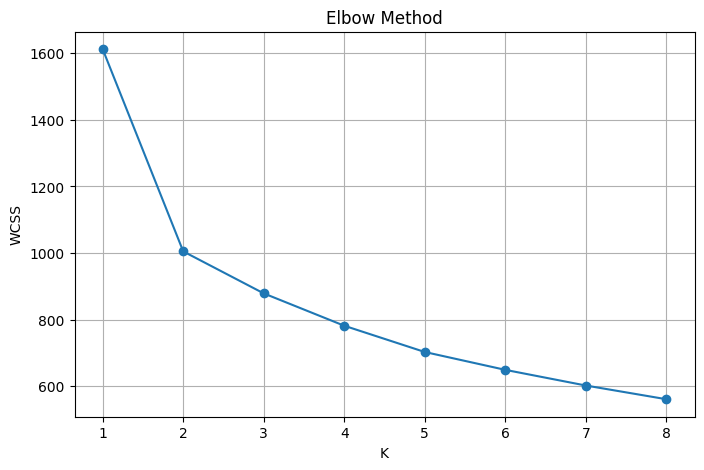

In [7]:
ks = range(1,9)
inertia = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(ks, inertia, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# 3 Hierarchical Clustering

### 3.1 Dendrogram

In the dendrogram, the vertical axis represents the distance or similarity level. Cutting the tree at the highest level of vertical separation clearly suggests 2 clusters. This results in an agreement with the Elbow Method (k=2) from Part 2, confirming that the data naturally splits into two primary groups.

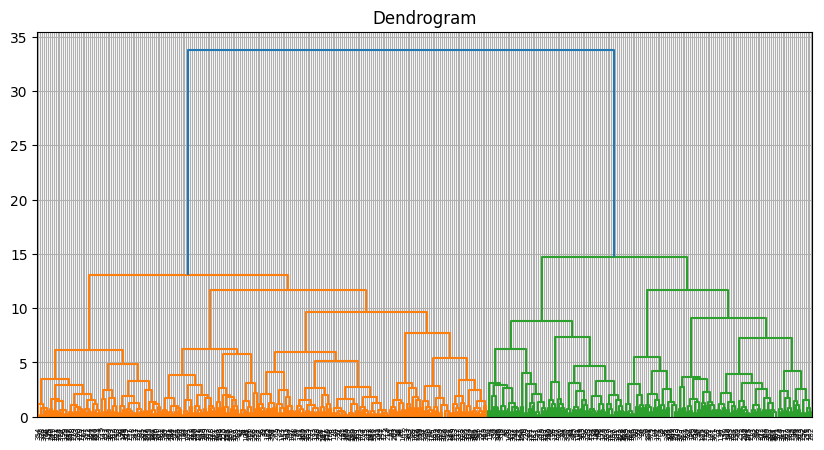

In [8]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()

In [9]:
agg = AgglomerativeClustering(n_clusters=2)
labels_h = agg.fit_predict(X_scaled)

print("Cluster sizes:", np.bincount(labels_h))

Cluster sizes: [169 234]


3.2 Linkage Comparison

Cluster sizes for K=2 linkage methods:
  single linkage: [401   2]
  complete linkage: [169 234]
  average linkage: [396   7]
  ward linkage: [169 234]


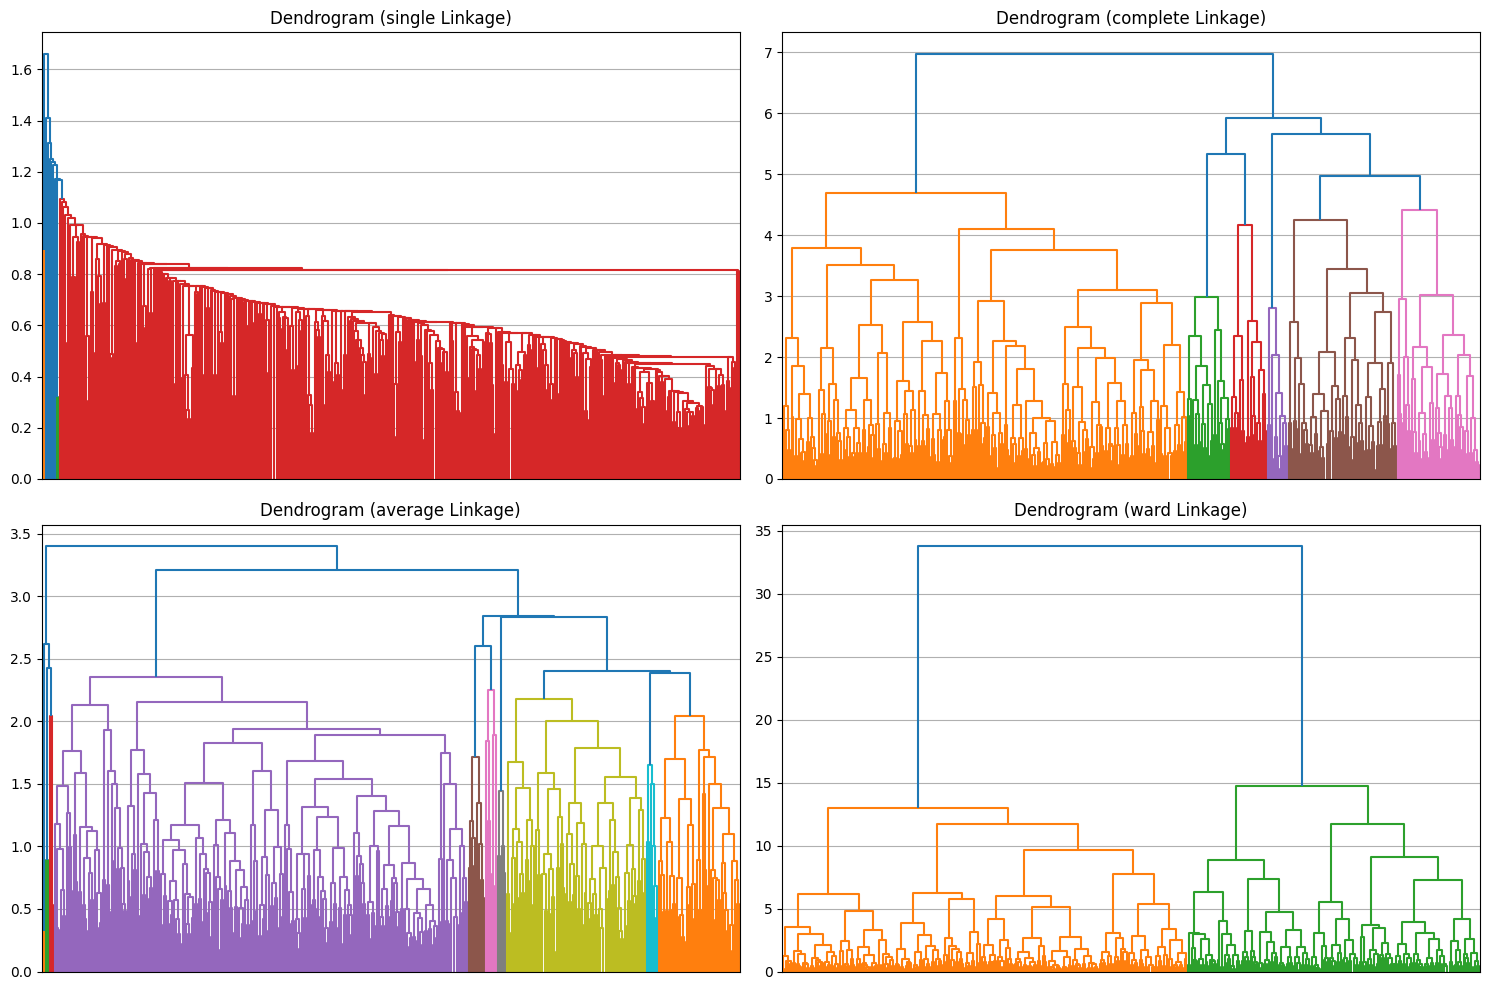

In [10]:
methods = ['single', 'complete', 'average', 'ward']

print("Cluster sizes for K=2 linkage methods:")
for method in methods:
    agg = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = agg.fit_predict(X_scaled)
    print(f"  {method} linkage: {np.bincount(labels)}")

# Plotting all four dendrograms side by side
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, method in enumerate(methods):
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, ax=axes[i], no_labels=True)
    axes[i].set_title(f"Dendrogram ({method} Linkage)")

plt.tight_layout()
plt.show()

Single linkage produced very different results from Ward's linkage because it is prone to the chaining effect. In single linkage, the distance between two clusters is defined as the minimum distance between any two points in those clusters. On this dataset, single linkage likely results in one giant cluster and several tiny ones.
Ward's linkage produces the most balanced clusters. It aims to minimize the variance within each cluster.
Single linkage the most imbalanced because it can leave out many individual points as separate clusters or join them to a single massive one.

For this student dataset, Ward's linkage is the most appropriate choice. Since our goal is likely to categorize students into distinct, interpretable performance groups, the balanced clusters produced by Ward's method are much more actionable for an administrator than the long, thin clusters produced by single linkage.

# 4 DBSCAN

4.1 Core, Border, Noise





In [11]:
db = DBSCAN(eps=0.8, min_samples=5)
labels_db = db.fit_predict(X_scaled)
df["cluster"] = labels_db

unique = set(labels_db)
print("Clusters:", len(unique)-1)
print("Noise points:", list(labels_db).count(-1))

noise_ids = df[df["cluster"] == -1]["student_id"].tolist()
print("\nNoise student IDs:")
print(noise_ids)

cluster_sizes = df["cluster"].value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes)

Clusters: 2
Noise points: 96

Noise student IDs:
[1, 2, 6, 7, 17, 21, 25, 29, 33, 35, 36, 37, 40, 42, 45, 51, 61, 62, 63, 65, 69, 71, 75, 80, 81, 90, 95, 100, 101, 111, 115, 118, 124, 128, 131, 144, 146, 147, 153, 156, 157, 161, 178, 180, 186, 205, 217, 223, 228, 230, 231, 232, 233, 234, 245, 249, 250, 251, 253, 254, 260, 262, 266, 271, 282, 284, 286, 293, 295, 296, 303, 304, 305, 307, 309, 316, 318, 320, 325, 327, 335, 339, 341, 348, 351, 355, 359, 366, 374, 375, 377, 378, 381, 387, 389, 393]

Cluster sizes:
cluster
-1     96
 0    300
 1      7
Name: count, dtype: int64


According to our results, we have 96 noise points, 300 students in cluster 0, and 7 students in cluster 1.

**Student ID 1**: This student has a very low `prev_exam_score` (30.2, scaled -2.15) and low `attendance_rate` (53.0, scaled -1.44), but their `sleep_hours` (6.2) is relatively average. This combination of extreme values and average values in others places them into a region far from the two main clusters.

 **Student ID 7**: Shows a significant imbalance between high `hours_studied` and very low `prev_exam_score`, which is not typical compared to the general trend of the dataset.

These resemble point anomaly, where they deviate from the rest of the dataset.

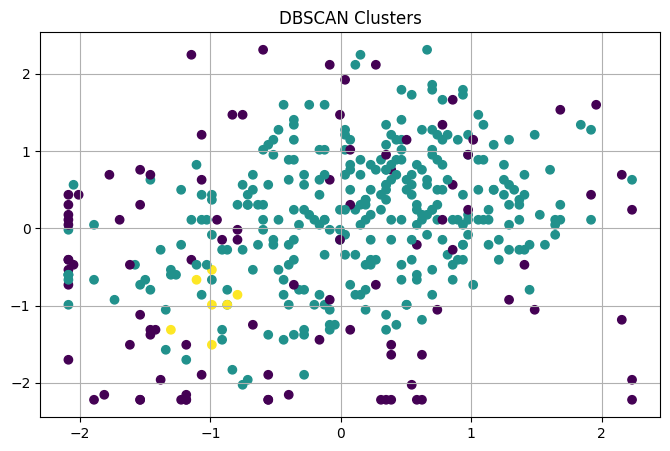

In [12]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_db)
plt.title("DBSCAN Clusters")
plt.show()

4.2 Parameter Tuning

When eps is too small, the number of noise points increase. When eps is too large, the number of noise points decrease, but it is possible that DBSCAN merges everything into one big cluster. Problem with too large eps is that even though noise disappears, the overall structure collapses.


--------------------------------------------------------------

Next, we experimented with different min_samples and found that as min_sample increases, it becomes much harder to form a cluster and the number of noise points increase.

--------------------------------------------------------------

DBSCAN automatically finds the number of clusters and noise/outliers. In our case, KNN is better because it resulted in more clean and interpretable clusters. DBSCAN is more suitable for anomaly detection.

In [13]:
eps_values = [0.5,0.8,1.0,1.5,2.0]

results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    clusters = len(set(labels))-1
    noise = list(labels).count(-1)

    results.append((eps, clusters, noise))

pd.DataFrame(results, columns=["eps","clusters","noise"])

,eps,clusters,noise
0,0.5,2,330
1,0.8,2,96
2,1.0,1,31
3,1.5,1,2
4,2.0,0,0


In [14]:
samples = [3,5,10,15]
results = []
for smp in samples:
    db = DBSCAN(eps=0.8, min_samples=smp)
    labels = db.fit_predict(X_scaled)

    clusters = len(set(labels))-1
    noise = list(labels).count(-1)

    results.append((smp, clusters, noise))

pd.DataFrame(results, columns=["smp","clusters","noise"])

,smp,clusters,noise
0,3,6,58
1,5,2,96
2,10,1,186
3,15,1,249


# 5 Method Comparison

In [15]:
#Comparison Table
comparison_df = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical (Ward)", "DBSCAN"],
    "Clusters Found": [len(np.unique(labels_np)), len(np.unique(labels_h)), len(set(labels_db)) - (1 if -1 in labels_db else 0)],
    "Noise Points": [0, 0, (labels_db == -1).sum()],
    "Implementation": ["Manual (NumPy)", "Sklearn", "Sklearn"]
})

display(comparison_df)

,Method,Clusters Found,Noise Points,Implementation
0,K-Means,2,0,Manual (NumPy)
1,Hierarchical (Ward),2,0,Sklearn
2,DBSCAN,2,96,Sklearn


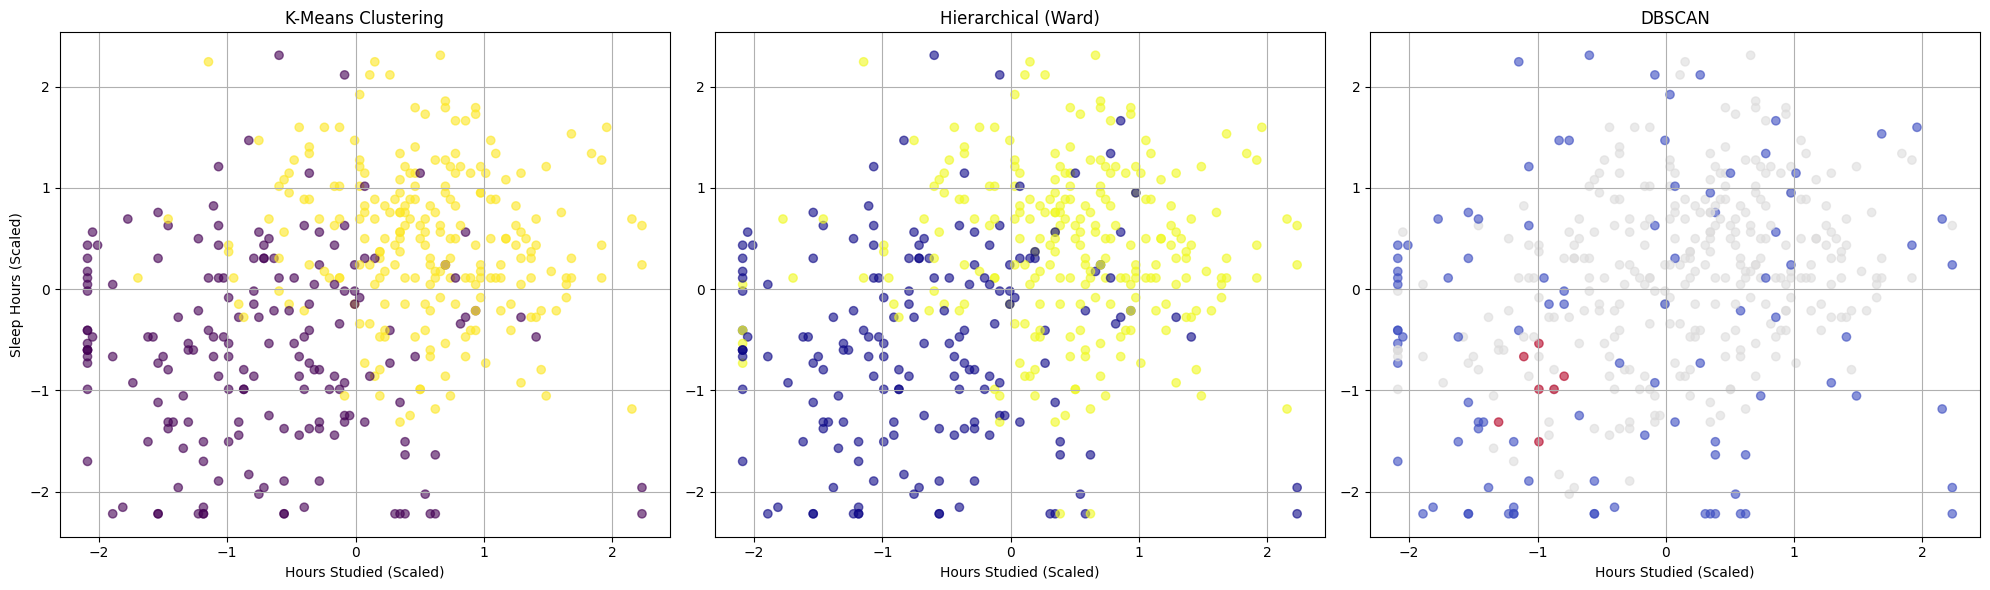

In [16]:
# Side-by-side visualization
# Using 'hours_studied' and 'sleep_hours' as the 2D feature pair for consistency
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_np, cmap='viridis', alpha=0.6)
axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Hours Studied (Scaled)")
axes[0].set_ylabel("Sleep Hours (Scaled)")

# Hierarchical
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_h, cmap='plasma', alpha=0.6)
axes[1].set_title("Hierarchical (Ward)")
axes[1].set_xlabel("Hours Studied (Scaled)")

# DBSCAN
axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_db, cmap='coolwarm', alpha=0.6)
axes[2].set_title("DBSCAN")
axes[2].set_xlabel("Hours Studied (Scaled)")

plt.tight_layout()
plt.show()

K-Means requires user to provide K in advance, which forces the data into a fixed number of clusters. K-means always assigns a data to a cluster, even if it doesn't belong. On the other hand, Hierarchical clustering builds a dendrogram, showing how students merge or split at different similarity levels. DBSCAN finds clusters of arbitrary shape and detects outliers automatically.

For an university administrator, I would suggest DBSCAN because it automatically detects clusters and noise/outliers so it would be more suitable to detect at-risk students.

# 6 Cluster vs Ground Truth




passed,0,1
cluster,,
0,145,27
1,30,198


Accuracy 0.8575


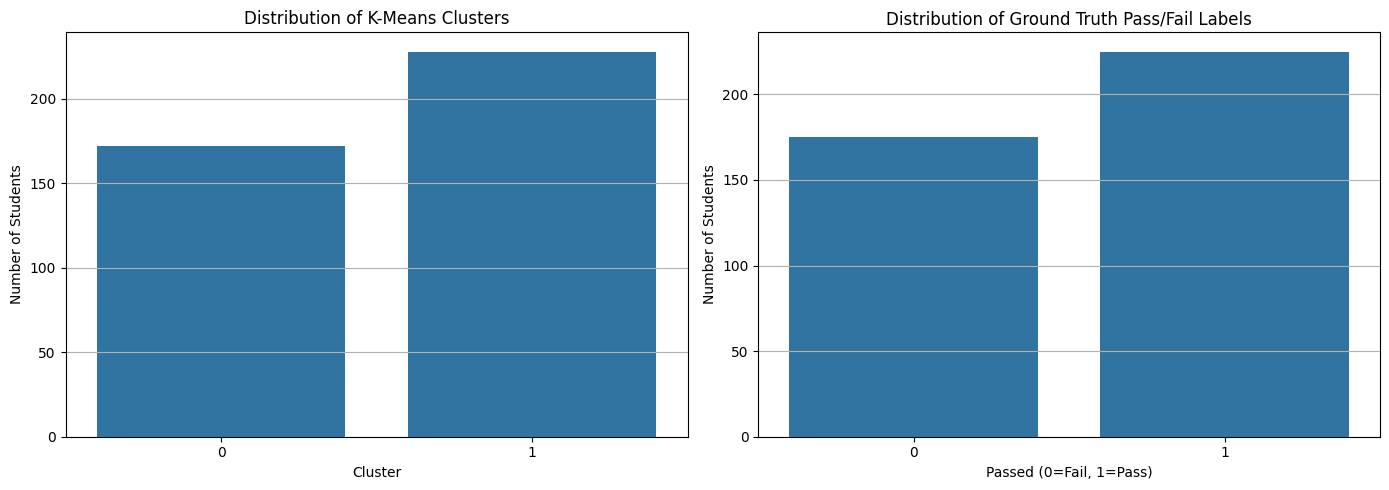

In [17]:
gt = pd.read_csv("p3_ground_truth.csv")

df_results = df.copy()
df_results["cluster"] = labels_np

merged = df_results.merge(gt, on="student_id")

ct = pd.crosstab(merged["cluster"], merged["passed"])
display(ct)

accuracy = np.sum(
    (merged["cluster"]==1)&(merged["passed"]==1) | (merged["cluster"]==0)&(merged["passed"]==0))/len(merged)

print("Accuracy", accuracy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plotting K-Means Clusters
sns.countplot(x='cluster', data=merged, ax=axes[0])
axes[0].set_title('Distribution of K-Means Clusters')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Students')

# Plotting Ground Truth Pass/Fail Labels
sns.countplot(x='passed', data=merged, ax=axes[1])
axes[1].set_title('Distribution of Ground Truth Pass/Fail Labels')
axes[1].set_xlabel('Passed (0=Fail, 1=Pass)')
axes[1].set_ylabel('Number of Students')

plt.tight_layout()
plt.show()

K-Means algorithm successfully discovered the pattern without ever seeing the labels, aligning to the true pass/fail label with 86% accuracy. The alignment is imperfect because factors such as outliers and near-boundary data can impact the outcome. For instance, small difference in feature-scaling can push the near-boundary students to wrong group. Unsupervised learning algorithm is suitable for exploring hidden structures, find patterns without labels, and find anomalies. Unsupervised methods are preferred when labels are scarce, unreliable, expensive to obtain, or when the goal is exploration rather than prediction.

#7. Summary & Final Reflection
In this project, K-Means clustering performed the best on this dataset, achieving an accuracy of 85.7% when compared to the ground truth. The student performance dataset made use of four continuous features that we scaled during the Data Preprocessing phase. These features were: hours studied, sleep hours, attendance rate and prior exam score. The features matched up very well with the core assumptions of K-Means since the clusters were roughly spherical, of similar size, and were well separated in the feature space. This conclusion was also supported by the elbow method, which clearly identified k=2 as the optimal number of clusters, since the reduction in within-cluster sum of squares (WCSS) was largest from k=1 to k=2 and decreased as more clusters were added. Hierarchical clustering (Ward linkage) arrived at a similar conclusion of a two cluster partition and provided greater corroborating evidence to our conclusion, we chose to go with K-Means as it provides more computational efficiency as well as better interpretability. DBSCAN was the weakest fit for this dataset. DBSCAN either merged a large amount of points into one cluster and labeled too many as noise (nearly 25%) depending on the epsilon parameter chosen. The weakness of DBSCAN could be attributed to the lack of density irregularities that make this method worthwhile.

During this project the most surprising was how well the unsupervised algorithm matched up with the labeled outcome variable "passed". Even though the algorithm never knew what labels possibly existed it was able to identify that our data could be separated using a binary label like pass/fail and was able to separate the points into the correct binary label with acceptable accuracy. This realization suggests that a student's academic performance is strongly influenced by a small number of measurable habits: how many hours does the student study, how many hours of sleep does the student get, and what percentage of classes does the student attend.

Having to build the K-Mans implementation from scratch using NumPy was very different from using the sklearn.cluster.KMeans command. We needed to write the code for initializing the centroids, computing the distance matrix (np.linalg.norm(X[:,None] - centroids, axis=2)), the label assignment loop, and the convergence check step by step. This made the mechanics of the algorithm much more clear rather than the abstractness of the sklearn implementation. We were able to clearly see why random initialization plays a major role as using different seeds can produce different local minima, which connects to why sklearn uses a default n_init=10, running the algorithm ten times and extracting the best result. Our NumPy implementation also caused us to have to deal with the edge case of empty clusters, which we handled by reinitializing to a random point. In sklearn this functionality is silently handled in the background. Tracking the WCSS across several iterations and plotting its convergence curve provided us with a visual reference and clue for what "convergence" actually means. All of these important understandings and calculations are done in sklearn's .fit() call, which is great for speeding up production but is detrimental to the understanding of what is actually happening in order for the algorithm to arrive at that end conclusion. This understanding is important for understanding when K-Means will work well or will not work well.

A concrete example where clustering is better than classification would be fraud detection in banking. Since, fraudulent transactions occur very infrequently and it is hard to know what the fraud will look like in advance since scammers evolve their tactics frequently. This causes classification to fail to detect fraudulent charges since a new type of scam will not have a label so the model will be unable to classify this as a fraudulent charge. On the contrary, clustering will use transaction features like amount, time of day, merchant category, geographic location, frequency of transactions, and previous spending behavior to identify transactions that deviate from normal patterns. The transaction anomalies will create tight clusters that security analysts can investigate, allowing them to discover new fraud tactics and create labeled datasets that a future classifier can use.

If our team had more time for this project we would have like to try more random seeds since K-Means is sensitive to initialization. Checking 20-30 seeds would allow us to check if the cluster assignments would stabilize and confirm if k=2 is the optimal amount of clusters.
